# 05 · Real vs shuffled structures (Rmd 6, Fig 3)

Reproduces `code_paper/6_Benchmark_shuffle_structures.Rmd` on the **2026 TCRen**. Tests
whether TCRen captures genuine TCR–peptide complementarity: for every pair of non-redundant
structures with **matching CDR3α, CDR3β and peptide lengths**, we keep structure 1's CDR3
contact geometry and its peptide, but substitute structure 2's CDR3 residues (by position).
A pair is **real** when structure 2 = structure 1 (native), **shuffled** otherwise.

If TCRen scores native CDR3–peptide pairings better (lower energy) than foreign ones, real
pairs separate from shuffled — quantified by ROC AUC, overall and per chain (Fig 3a/3c).
Fig 3d checks that a structure's TRA and TRB contact energies are correlated.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from collections import defaultdict
import numpy as np, polars as pl
from tcren.potential import mj, keskin

R = 'results_new'
AA = list('LFIMVWYCHAGPTSQNDERK'); AIDX = {a: i for i, a in enumerate(AA)}

contacts = pl.read_csv(f'{R}/contacts_2026.csv')
markup = pl.read_csv(f'{R}/markup_2026.csv')
nonred = set(pl.read_csv(f'{R}/TCRen_2026_LOO.csv')['pdb.id'].unique().to_list())

def mat_from(df, vcol='value'):
    m = np.zeros((20, 20))
    for r in df.iter_rows(named=True):
        i, j = AIDX.get(r['residue.aa.from']), AIDX.get(r['residue.aa.to'])
        if i is not None and j is not None:
            m[i, j] = r[vcol]
    return m

pots = {'TCRen': mat_from(pl.read_csv(f'{R}/TCRen_2026.csv')),
        'MJ': mat_from(mj().matrix), 'Keskin': mat_from(keskin().matrix)}

# Per-structure CDR3 sequences (as aa-index arrays) and lengths, for the non-redundant set.
def idx(seq):
    return np.array([AIDX[a] for a in seq]) if seq and all(a in AIDX for a in seq) else None

cdr3, lens = {}, {}
for r in markup.iter_rows(named=True):
    if r['pdb.id'] not in nonred:
        continue
    a, b, p = idx(r['cdr3a']), idx(r['cdr3b']), r['peptide']
    if a is None or b is None or not p:
        continue
    cdr3[r['pdb.id']] = {'TRA': a, 'TRB': b}
    lens[r['pdb.id']] = (len(a), len(b), len(p))
print(f'structures usable for shuffling: {len(cdr3)}')

structures usable for shuffling: 215


In [2]:
# CDR3 contact template per structure: (position-in-CDR3, peptide-aa-index) per chain.
cdr3c = contacts.filter((pl.col('region.type.from') == 'CDR3') &
                        (pl.col('chain.type.from').is_in(['TRA', 'TRB'])) &
                        (pl.col('pdb.id').is_in(list(cdr3))))
templ = {pid: {'TRA': ([], []), 'TRB': ([], [])} for pid in cdr3}
for r in cdr3c.iter_rows(named=True):
    pid, ch = r['pdb.id'], r['chain.type.from']
    if r['pos.from'] is None or r['residue.aa.to'] not in AIDX:
        continue
    templ[pid][ch][0].append(r['pos.from']); templ[pid][ch][1].append(AIDX[r['residue.aa.to']])
templ = {pid: {ch: (np.array(v[0]), np.array(v[1])) for ch, v in d.items()} for pid, d in templ.items()}

# Group by (cdr3a len, cdr3b len, peptide len); only same-shape pairs can be shuffled.
groups = defaultdict(list)
for pid, shape in lens.items():
    groups[shape].append(pid)
groups = {k: v for k, v in groups.items() if len(v) >= 2}
print(f'shape groups with >=2 structures: {len(groups)}; '
      f'structures in them: {sum(len(v) for v in groups.values())}')

shape groups with >=2 structures: 43; structures in them: 130


In [3]:
# Score every same-shape pair: structure-1 geometry+peptide, structure-2 CDR3 residues.
real, eA, eB, eT = [], {k: [] for k in pots}, {k: [] for k in pots}, {k: [] for k in pots}
for members in groups.values():
    A = np.stack([cdr3[p]['TRA'] for p in members])          # (k, La)
    B = np.stack([cdr3[p]['TRB'] for p in members])          # (k, Lb)
    for i, pid1 in enumerate(members):
        (posA, pepA), (posB, pepB) = templ[pid1]['TRA'], templ[pid1]['TRB']
        real.extend([j == i for j in range(len(members))])
        for name, M in pots.items():
            ea = M[A[:, posA], pepA[None, :]].sum(axis=1) if len(posA) else np.zeros(len(members))
            eb = M[B[:, posB], pepB[None, :]].sum(axis=1) if len(posB) else np.zeros(len(members))
            eA[name].extend(ea); eB[name].extend(eb); eT[name].extend(ea + eb)
real = np.array(real)
print(f'pairs: {len(real)} ({real.sum()} real / {(~real).sum()} shuffled)')

from sklearn.metrics import roc_auc_score
auc_fig3a = pl.DataFrame([{'potential': k, 'AUC': round(roc_auc_score(real, -np.array(eT[k])), 2)}
                          for k in pots])
auc_fig3a.write_csv(f'{R}/benchmark_shuffle_auc.csv')
auc_fig3a

pairs: 468 (130 real / 338 shuffled)


potential,AUC
str,f64
"""TCRen""",0.73
"""MJ""",0.52
"""Keskin""",0.51


In [4]:
# Per-chain discrimination for TCRen (Fig 3c): TRA, TRB, TRA+TRB.
auc_fig3c = pl.DataFrame([
    {'chain': 'TRA+TRB', 'AUC': round(roc_auc_score(real, -np.array(eT['TCRen'])), 2)},
    {'chain': 'TRA', 'AUC': round(roc_auc_score(real, -np.array(eA['TCRen'])), 2)},
    {'chain': 'TRB', 'AUC': round(roc_auc_score(real, -np.array(eB['TCRen'])), 2)},
])
auc_fig3c

chain,AUC
str,f64
"""TRA+TRB""",0.73
"""TRA""",0.63
"""TRB""",0.71


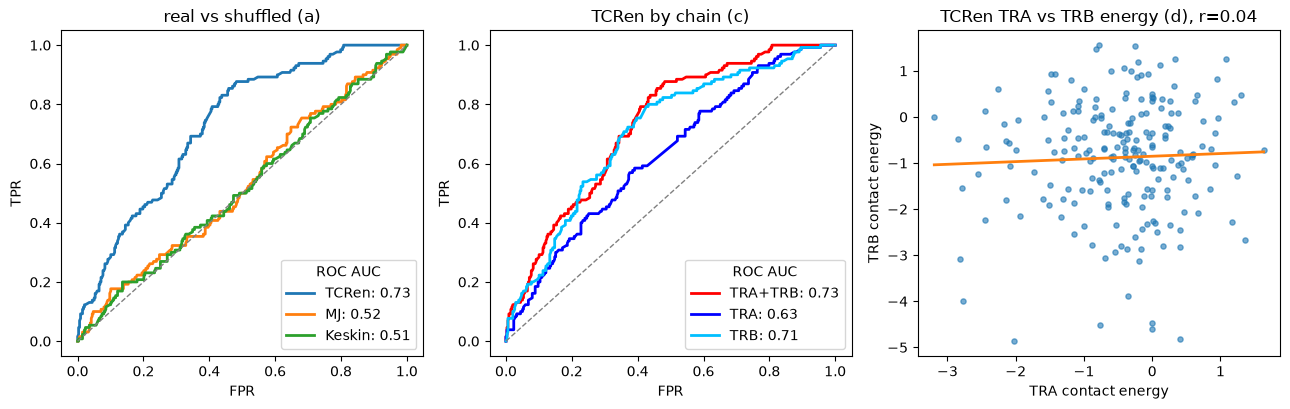

In [5]:
# Figure 3: (a) ROC by potential, (c) ROC by chain, (d) per-structure TRA vs TRB TCRen energy.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for name in pots:
    fpr, tpr, _ = roc_curve(real, -np.array(eT[name]))
    axes[0].plot(fpr, tpr, lw=2, label=f'{name}: {roc_auc_score(real, -np.array(eT[name])):.2f}')
axes[0].plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
axes[0].set_title('real vs shuffled (a)'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(title='ROC AUC', loc='lower right')

for ch, e, c in [('TRA+TRB', eT, 'red'), ('TRA', eA, 'blue'), ('TRB', eB, 'deepskyblue')]:
    fpr, tpr, _ = roc_curve(real, -np.array(e['TCRen']))
    axes[1].plot(fpr, tpr, lw=2, c=c, label=f'{ch}: {roc_auc_score(real, -np.array(e["TCRen"])):.2f}')
axes[1].plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
axes[1].set_title('TCRen by chain (c)'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(title='ROC AUC', loc='lower right')

# Fig 3d: native per-structure TRA vs TRB energy over ALL TCR-peptide contacts.
Mt = pots['TCRen']
allc = contacts.filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']) & pl.col('pdb.id').is_in(list(cdr3)))
per = defaultdict(lambda: {'TRA': 0.0, 'TRB': 0.0})
for r in allc.iter_rows(named=True):
    fi, ti = AIDX.get(r['residue.aa.from']), AIDX.get(r['residue.aa.to'])
    if fi is not None and ti is not None:
        per[r['pdb.id']][r['chain.type.from']] += Mt[fi, ti]
tra = [v['TRA'] for v in per.values()]; trb = [v['TRB'] for v in per.values()]
axes[2].scatter(tra, trb, s=14, alpha=0.6)
b, a = np.polyfit(tra, trb, 1); xs = np.array([min(tra), max(tra)])
axes[2].plot(xs, a + b * xs, c='C1', lw=2)
rho = np.corrcoef(tra, trb)[0, 1]
axes[2].set_title(f'TCRen TRA vs TRB energy (d), r={rho:.2f}')
axes[2].set_xlabel('TRA contact energy'); axes[2].set_ylabel('TRB contact energy')
plt.tight_layout()